<a href="https://colab.research.google.com/github/arukima12/Retail-Analysis-and-footfall-tracking/blob/main/Retail_Analytics_%26_Footfall_Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Re-install the required libraries
!pip install -q ultralytics kaggle

# 2. Authenticate Kaggle (using your saved Secret)
from google.colab import userdata
import os
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

# 3. Re-download and unzip the dataset
!kaggle datasets download -d chaozhuang/mall-dataset
!unzip -q mall-dataset.zip -d mall_data

print("Environment rebuilt! You are ready to run the tracking code.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.5 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/chaozhuang/mall-dataset
License(s): apache-2.0
100% 87.1M/87.1M [00:07<00:00, 11.5MB/s]

Environment rebuilt! You are ready to run the tracking code.


In [2]:
!pip install -q kaggle

from google.colab import userdata
import os

print("Authenticating securely...")
# Fetch your Kaggle token from Colab's hidden secrets
os.environ["KAGGLE_API_TOKEN"] = userdata.get('KAGGLE_API_TOKEN')

print("Downloading dataset...")
# Download the Mall Dataset directly
!kaggle datasets download -d chaozhuang/mall-dataset

print("Unzipping files (this might take a minute)...")
# Unzip the data into a new folder
!unzip -q mall-dataset.zip -d mall_data

print("Dataset downloaded and extracted successfully!")

Authenticating securely...
Dataset URL: https://www.kaggle.com/datasets/chaozhuang/mall-dataset
License(s): apache-2.0
100% 87.1M/87.1M [00:00<00:00, 98.8MB/s]

Unzipping files (this might take a minute)...
Dataset downloaded and extracted successfully!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading YOLOv8s model...
Testing detection on: mall_data/frames/frames/seq_000550.jpg

image 1/1 /content/mall_data/frames/frames/seq_000550.jpg: 480x640 15 persons, 693.8ms
Speed: 7.7ms preprocess, 693.8ms inference, 52.7ms postprocess per image at shape (1, 3, 480, 640)


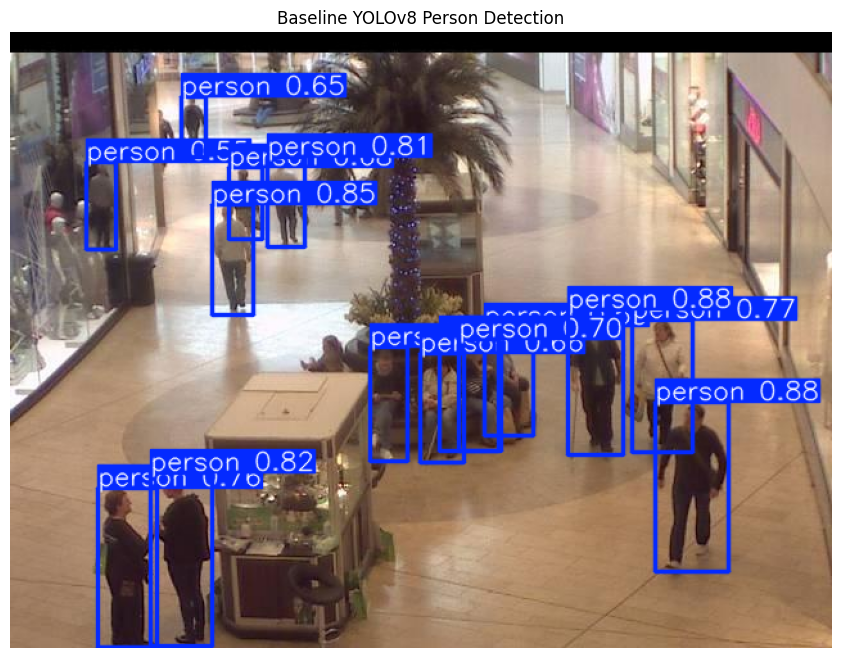

In [3]:
# 1. Install the Ultralytics library (the official home of YOLOv8)
!pip install -q ultralytics

import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("Loading YOLOv8s model...")
# 2. Load the pre-trained model (it will auto-download the weights file)
model = YOLO('yolov8s.pt')

# 3. Grab the first image frame from our extracted dataset
# Using glob to search recursively just in case the zip had nested folders
image_paths = glob.glob('mall_data/**/*.jpg', recursive=True)

if not image_paths:
    print("Error: Could not find any .jpg images in the mall_data folder.")
else:
    test_image_path = image_paths[0]
    print(f"Testing detection on: {test_image_path}")

    # 4. Run the image through the YOLO model
    # Note for your report:
    # classes=[0] forces YOLO to ONLY look for 'persons' (class 0 in the COCO dataset).
    # conf=0.3 means we only draw boxes if the model is at least 30% confident.
    results = model(test_image_path, classes=[0], conf=0.3)

    # 5. Draw the bounding boxes on the image
    annotated_frame = results[0].plot()

    # 6. Display the image
    # OpenCV reads images in BGR format, but Matplotlib displays in RGB.
    # We convert it here so the colors look normal!
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')
    plt.title("Baseline YOLOv8 Person Detection")
    plt.show()

In [3]:
import cv2
import glob
import os
from ultralytics import YOLO

# 1. Load the model
model = YOLO('yolov8s.pt')

# 2. Get the images in sequential order
# Based on your screenshot, the path has nested 'frames' folders
image_paths = sorted(glob.glob('mall_data/frames/frames/*.jpg'))

# Let's process just the first 300 frames to test it quickly (about 10 seconds of video)
test_frames = image_paths[:300]

# 3. Setup the Video Writer to save our output
first_frame = cv2.imread(test_frames[0])
height, width, _ = first_frame.shape
video_output_path = 'footfall_tracking_demo.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(video_output_path, fourcc, 30.0, (width, height))

# 4. Define our counting logic variables
LINE_Y = 350 # A horizontal line roughly across the middle of the frame
track_history = {} # To remember where people were in the previous frame
people_up = 0
people_down = 0

print("Processing video frames and tracking objects... this will take a minute.")

# 5. Loop through the frames
for frame_path in test_frames:
    frame = cv2.imread(frame_path)

    # Run YOLO tracking (persist=True keeps IDs across frames)
    results = model.track(frame, classes=[0], conf=0.3, persist=True, tracker="bytetrack.yaml", verbose=False)

    # Draw our virtual counting line
    cv2.line(frame, (0, LINE_Y), (width, LINE_Y), (0, 255, 255), 2) # Yellow line

    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        track_ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, track_id in zip(boxes, track_ids):
            x1, y1, x2, y2 = box

            # Calculate the center point of the person's bounding box
            cx = int((x1 + x2) / 2)
            cy = int((y1 + y2) / 2)

            # Draw a circle at the center and a box around the person
            cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)
            cv2.rectangle(frame, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
            cv2.putText(frame, f"ID: {track_id}", (int(x1), int(y1) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

            # --- COUNTING LOGIC ---
            if track_id in track_history:
                prev_cy = track_history[track_id]

                # Check if they crossed the line going DOWN
                if prev_cy < LINE_Y and cy >= LINE_Y:
                    people_down += 1

                # Check if they crossed the line going UP
                elif prev_cy > LINE_Y and cy <= LINE_Y:
                    people_up += 1

            # Update history for the next frame
            track_history[track_id] = cy

    # Display the live counters on the video
    cv2.putText(frame, f"Walking UP: {people_up}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
    cv2.putText(frame, f"Walking DOWN: {people_down}", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)

    # Write the frame to our video file
    out.write(frame)

out.release()
print(f"Done! Video saved as {video_output_path}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Processing video frames and tracking objects... this will take a minute.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 93ms
Prepared 1 package in 27ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Done! Video saved as footfall_tracking_demo.mp4
